# AeroFit Treadmill — Customer Profiling & Probability Analysis

**Business Case Study | Descriptive Analytics & Probability**

## 1. Problem Statement

Aerofit's market research team wants to understand **who buys which treadmill** (KP281, KP481, KP781) so that store staff can **recommend the right product to a new customer** based on that customer's profile (age, gender, income, fitness level, intended usage, etc.).

This notebook:
1. Explores and cleans the dataset.
2. Profiles customers for each product using univariate & bivariate analysis.
3. Builds two-way contingency tables and computes marginal & conditional probabilities.
4. Converts findings into **actionable business recommendations**.

**Product Portfolio**

| Product | Positioning | Price |
|---|---|---|
| KP281 | Entry-level | \$1,500 |
| KP481 | Mid-level runners | \$1,750 |
| KP781 | Advanced features | \$2,500 |


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

df = pd.read_csv("aerofit_treadmill.csv")
print(df.head())


  Product  Age  Gender  Education MaritalStatus  Usage  Fitness  Income  Miles
0   KP281   18    Male         14        Single      3        4   29562    112
1   KP281   19    Male         15        Single      2        3   31836     75
2   KP281   19  Female         14     Partnered      4        3   30699     66
3   KP281   19    Male         12        Single      3        3   32973     85
4   KP281   20    Male         13     Partnered      4        2   35247     47


## 2. Basic Data Checks

Shape, data types, missing values, duplicates, and conversion of categorical columns to `category` dtype.

In [4]:
print("Shape of dataset:", df.shape)
print()
print("Column info:")
df.info()


Shape of dataset: (180, 9)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Number of duplicate rows:", df.duplicated().sum())


Missing values per column:
Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64

Number of duplicate rows: 0


In [4]:
# Convert categorical columns to 'category' dtype
cat_cols = ["Product", "Gender", "MaritalStatus"]
for c in cat_cols:
    df[c] = df[c].astype("category")

print(df.dtypes)


Product          category
Age                 int64
Gender           category
Education           int64
MaritalStatus    category
Usage               int64
Fitness             int64
Income              int64
Miles               int64
dtype: object


In [5]:
print("Statistical summary (numerical features):")
print(df.describe().T)


Statistical summary (numerical features):
           count          mean           std      min       25%      50%  \
Age        180.0     28.788889      6.943498     18.0     24.00     26.0   
Education  180.0     15.572222      1.617055     12.0     14.00     16.0   
Usage      180.0      3.455556      1.084797      2.0      3.00      3.0   
Fitness    180.0      3.311111      0.958869      1.0      3.00      3.0   
Income     180.0  53719.577778  16506.684226  29562.0  44058.75  50596.5   
Miles      180.0    103.194444     51.863605     21.0     66.00     94.0   

                75%       max  
Age           33.00      50.0  
Education     16.00      21.0  
Usage          4.00       7.0  
Fitness        4.00       5.0  
Income     58668.00  104581.0  
Miles        114.75     360.0  


**Observations**
- Dataset has **180 rows and 9 columns**, no missing values and no duplicate rows — data is clean.
- `Product`, `Gender`, `MaritalStatus` are categorical; `Age`, `Education`, `Usage`, `Fitness`, `Income`, `Miles` are numeric.
- `Income` and `Miles` show a large gap between **mean and median** (mean > median) — a strong hint of **right-skewed distributions with high-end outliers**, which we confirm with boxplots below.
- `Age` ranges 18–50, `Education` 12–21 years, `Usage` 2–7 times/week, `Fitness` 1–5 self-rating, `Income` \$29,562–\$104,581, `Miles` 21–360.

## 3. Non-Graphical Analysis — Value Counts & Unique Attributes

In [6]:
for col in ["Product", "Gender", "MaritalStatus", "Usage", "Fitness"]:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- Product ---
Product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64

--- Gender ---
Gender
Male      104
Female     76
Name: count, dtype: int64

--- MaritalStatus ---
MaritalStatus
Partnered    107
Single        73
Name: count, dtype: int64

--- Usage ---
Usage
3    69
4    52
2    33
5    17
6     7
7     2
Name: count, dtype: int64

--- Fitness ---
Fitness
3    97
5    31
2    26
4    24
1     2
Name: count, dtype: int64



In [7]:
print("Unique value counts per column:")
print(df.nunique())


Unique value counts per column:
Product           3
Age              32
Gender            2
Education         8
MaritalStatus     2
Usage             6
Fitness           5
Income           62
Miles            37
dtype: int64


**Observations**
- **KP281** is the best-selling model (80 units, 44.4%), followed by **KP481** (60 units, 33.3%) and **KP781** (40 units, 22.2%).
- Gender split: 104 Male vs 76 Female overall.
- MaritalStatus: 107 Partnered vs 73 Single.
- Most customers plan to use the treadmill **3–4 times/week** and self-rate fitness as **3**.

## 4. Missing Value & Outlier Detection

We already confirmed there are **no missing values**. Now we detect outliers using boxplots on the continuous variables.

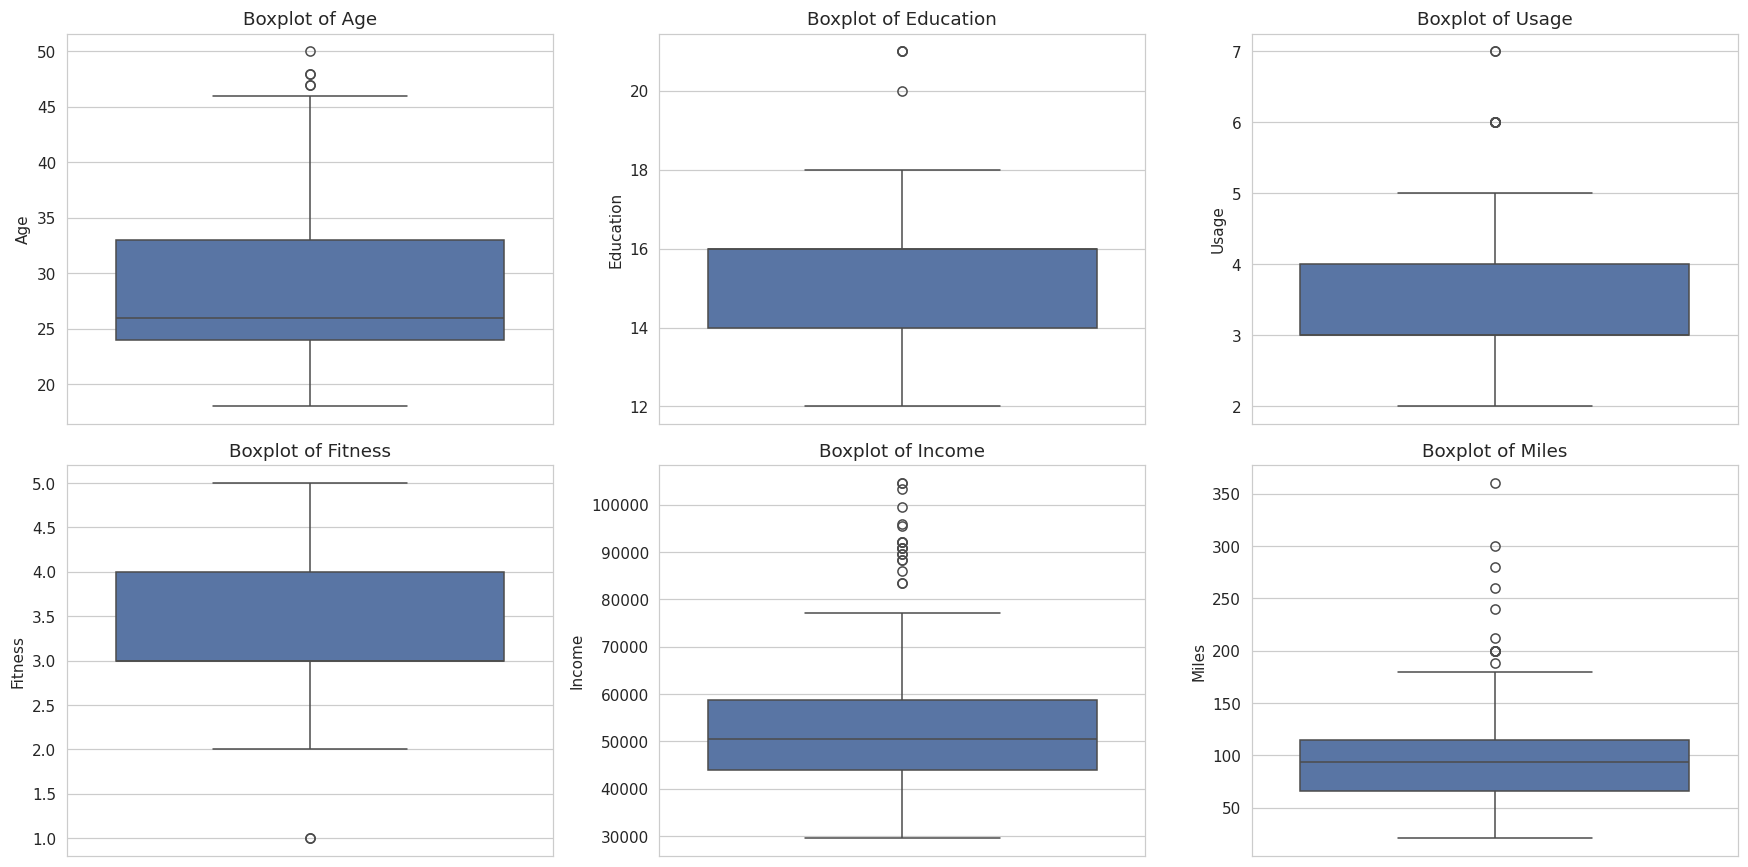

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
num_cols = ["Age", "Education", "Usage", "Fitness", "Income", "Miles"]
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()


In [9]:
def outlier_summary(col):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    return {"Q1": q1, "Q3": q3, "IQR": iqr, "Lower": lower, "Upper": upper, "n_outliers": n_out}

outlier_table = pd.DataFrame({c: outlier_summary(c) for c in num_cols}).T
print(outlier_table)


                 Q1        Q3       IQR      Lower      Upper  n_outliers
Age           24.00     33.00      9.00     10.500     46.500         5.0
Education     14.00     16.00      2.00     11.000     19.000         4.0
Usage          3.00      4.00      1.00      1.500      5.500         9.0
Fitness        3.00      4.00      1.00      1.500      5.500         2.0
Income     44058.75  58668.00  14609.25  22144.875  80581.875        19.0
Miles         66.00    114.75     48.75     -7.125    187.875        13.0


**Observations**
- **Income** and **Miles** have the most pronounced outliers (high-income customers and very-high-mileage customers, mostly **KP781 buyers**) — expected since KP781 is the premium/advanced model bought by fitness enthusiasts and higher earners.
- A few outliers also appear in **Usage** and **Fitness** (customers planning very frequent use / rating themselves 5) — again disproportionately KP781 buyers.
- **Age** and **Education** have only mild outliers.
- These are **not data errors** — they represent a genuine, distinct high-usage/high-income customer segment, so we do not drop them; they are core to profiling the KP781 buyer.

## 5. Univariate Analysis

### 5.1 Continuous variables — distribution (histograms)

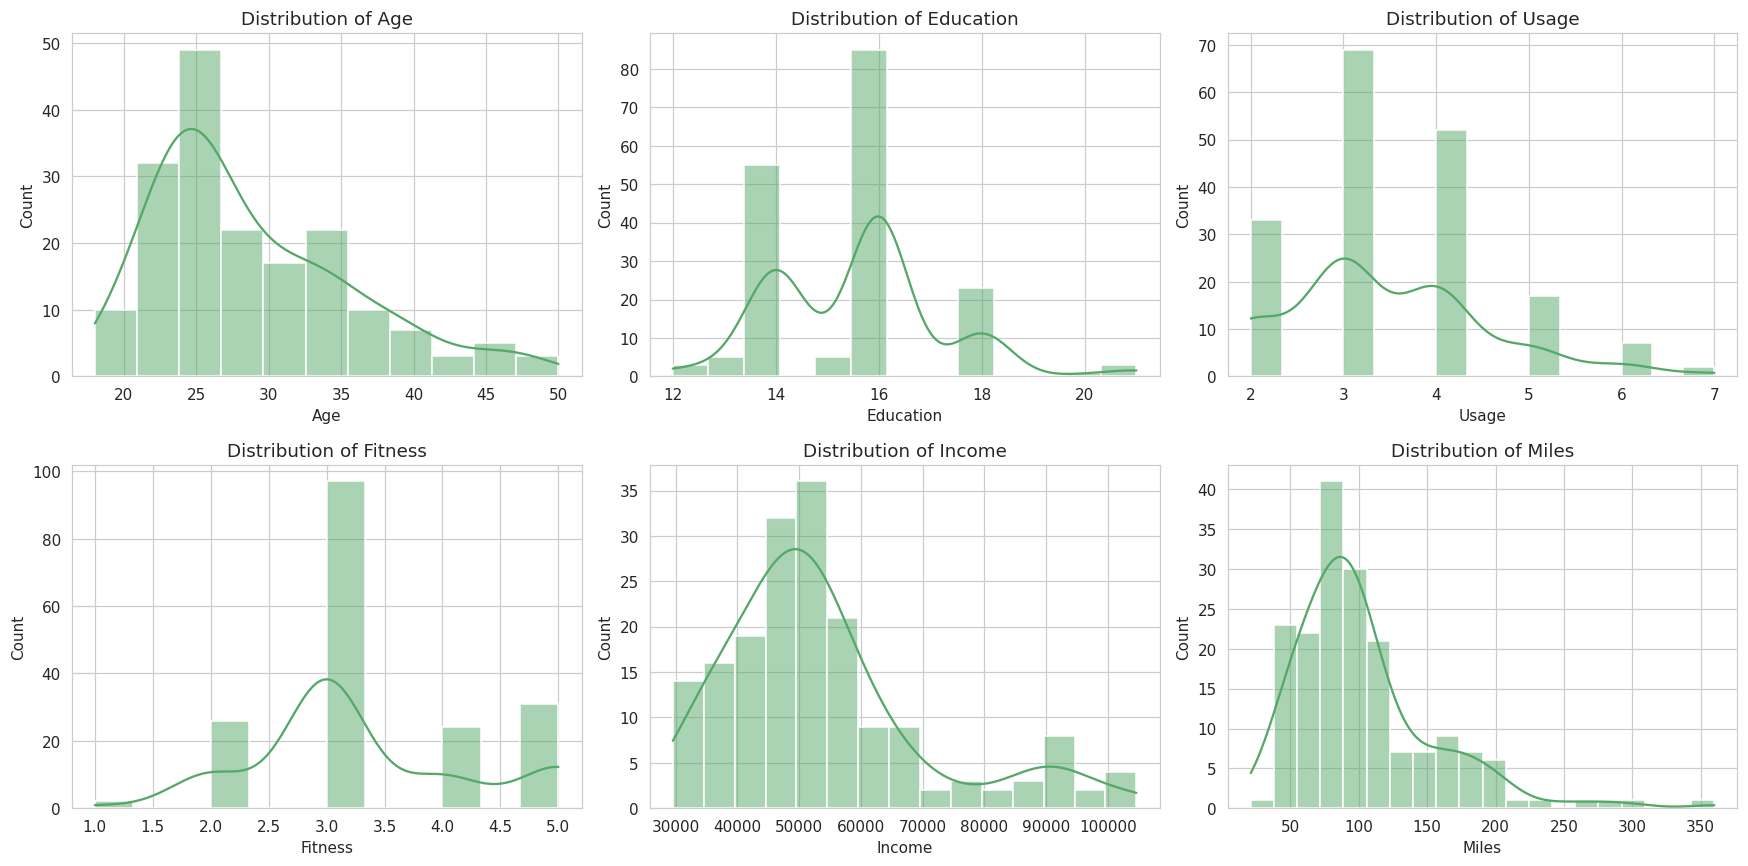

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#55A868")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


### 5.2 Categorical variables — count plots

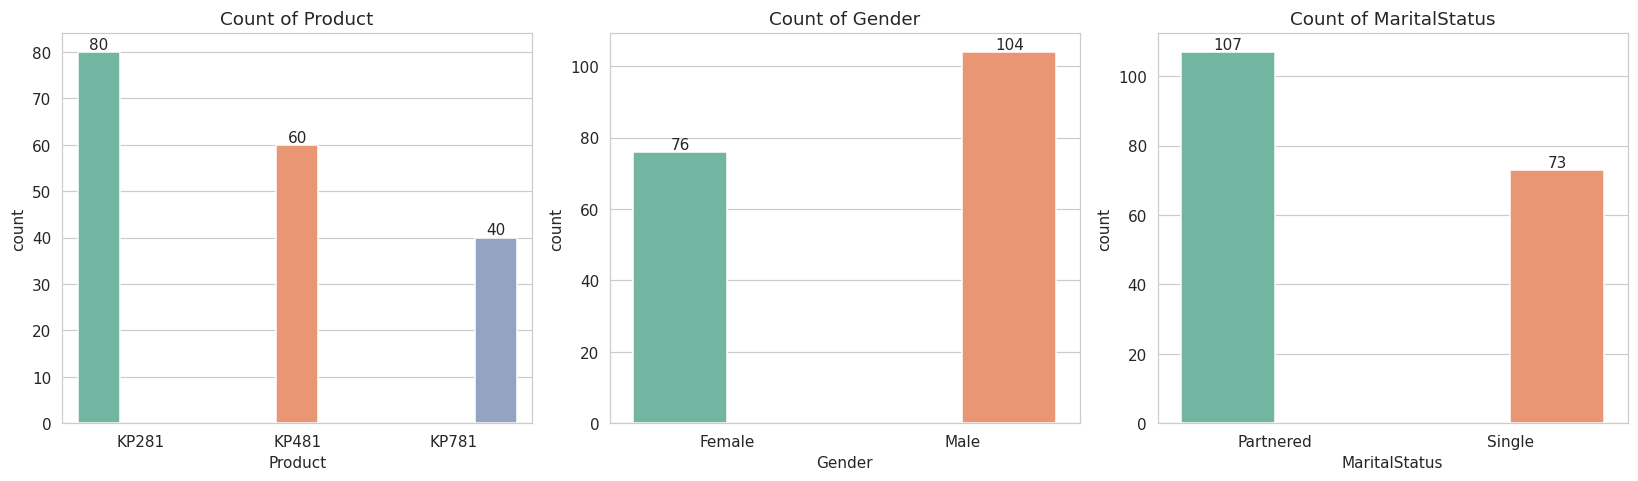

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["Product", "Gender", "MaritalStatus"]):
    sns.countplot(x=df[col], ax=ax, palette="Set2", hue=df[col], legend=False)
    ax.set_title(f"Count of {col}")
    for p in ax.patches:
        ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()),
                    ha="center", va="bottom")
plt.tight_layout()
plt.show()


**Observations**
- **Age** is right-skewed — most customers are 23–33 years old, with fewer older buyers.
- **Income** and **Miles** are right-skewed with a long tail of high-income / high-mileage buyers.
- **Usage** and **Fitness** are roughly centered at 3–4 with a spike at the higher end (5/6/7) coming largely from advanced users.
- **Education** clusters tightly around 14–16 years (typical of graduate-level education), with a smaller tail up to 21 years.
- Product counts confirm KP281 > KP481 > KP781; Gender is skewed toward Male; MaritalStatus skewed toward Partnered.

## 6. Bivariate Analysis — Effect of Customer Attributes on Product Purchased

### 6.1 Continuous variables vs Product (boxplots)

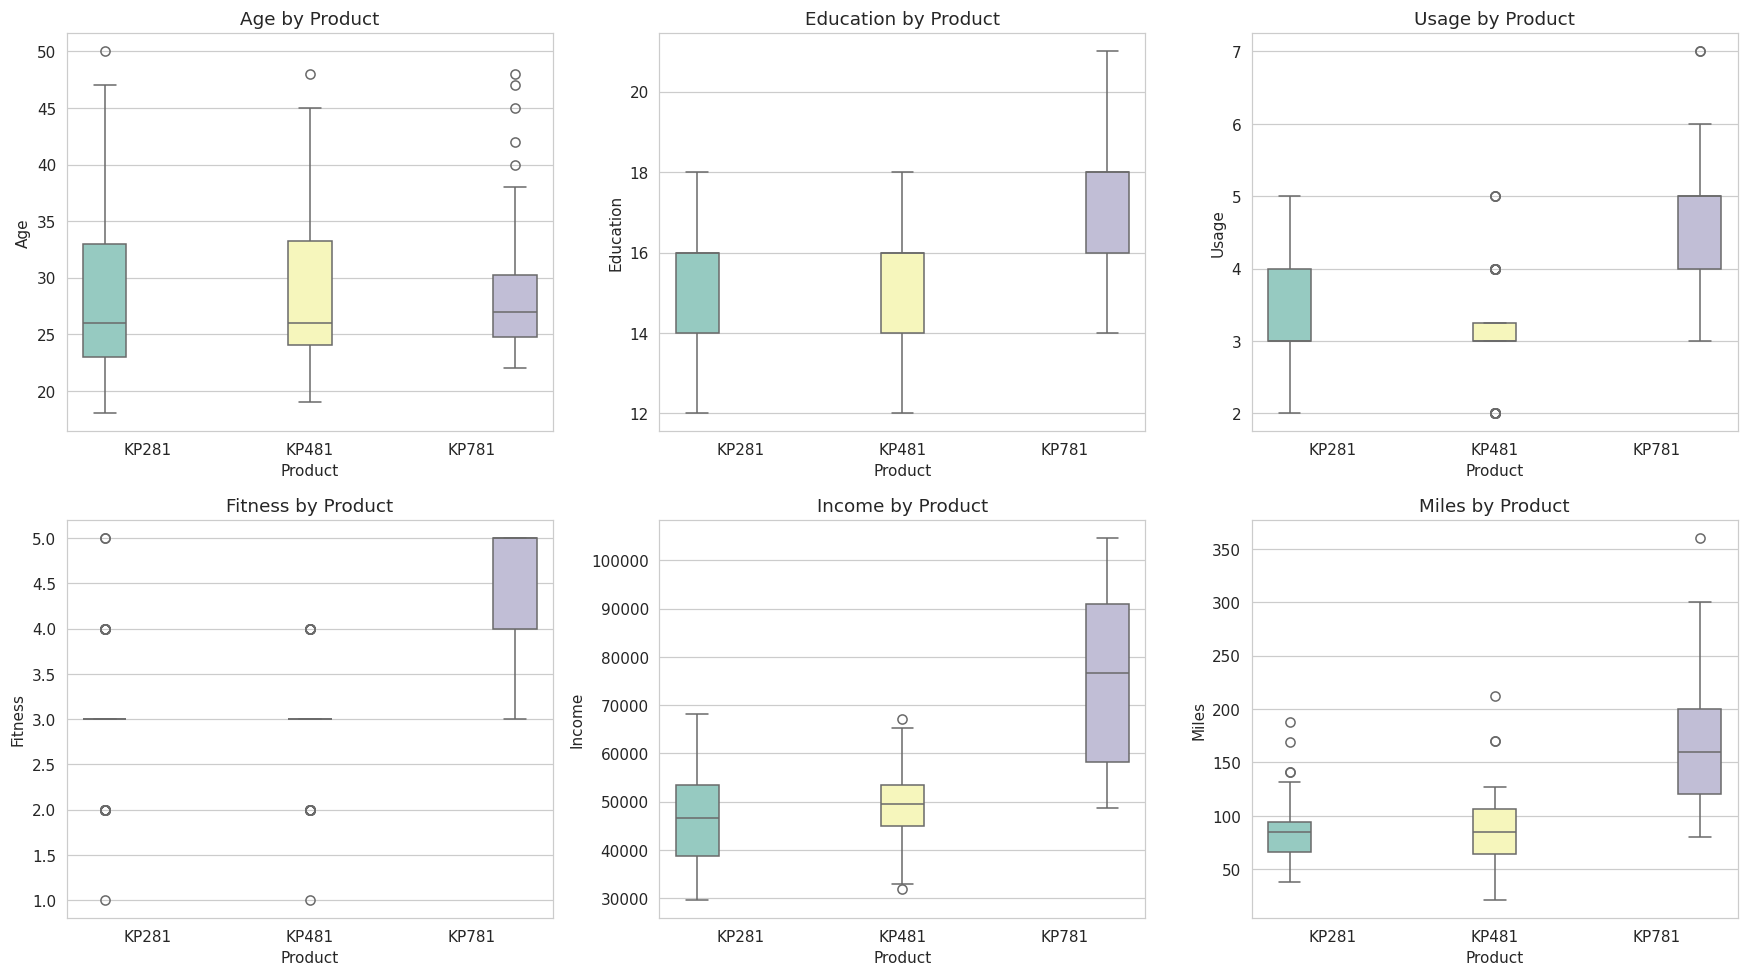

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x="Product", y=col, data=df, ax=ax, palette="Set3", hue="Product", legend=False)
    ax.set_title(f"{col} by Product")
plt.tight_layout()
plt.show()


### 6.2 Categorical variables vs Product (count plots)

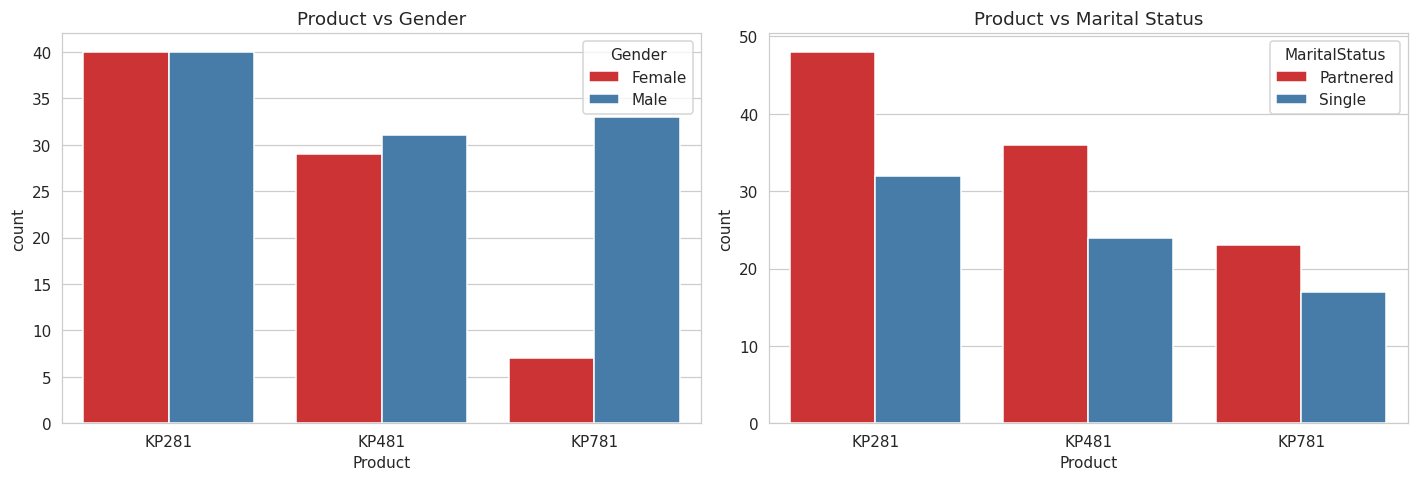

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(x="Product", hue="Gender", data=df, ax=axes[0], palette="Set1")
axes[0].set_title("Product vs Gender")
sns.countplot(x="Product", hue="MaritalStatus", data=df, ax=axes[1], palette="Set1")
axes[1].set_title("Product vs Marital Status")
plt.tight_layout()
plt.show()


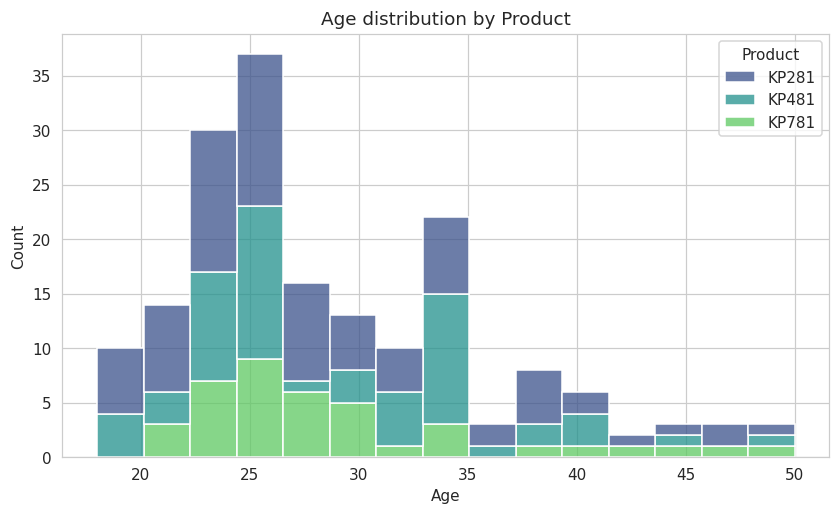

In [14]:
# Age distribution by product (histogram)
plt.figure(figsize=(9,5))
sns.histplot(data=df, x="Age", hue="Product", multiple="stack", bins=15, palette="viridis")
plt.title("Age distribution by Product")
plt.show()


**Observations**
- **KP781 buyers** are distinctly different: **higher Income, higher Usage, higher self-rated Fitness, and higher Miles** than KP281/KP481 buyers — clear, almost non-overlapping boxplots on Income and Miles.
- **KP281 and KP481 buyers look similar** on Income, Usage, Fitness, and Miles — the biggest visible difference between these two is not lifestyle but **Gender split** (see below) and small Age differences.
- **Gender:** KP781 is bought overwhelmingly by **males** — very few females purchase the advanced model. KP281 has a fairly even Gender mix; KP481 is also fairly balanced.
- **Marital status** shows Partnered customers outnumber Single customers in every product, roughly proportional to the overall base rate — marital status alone doesn't strongly steer product choice.
- **Age** distribution is broadly similar across products, with KP781 buyers slightly concentrated in the mid-20s to mid-30s range.

## 7. Correlation Analysis

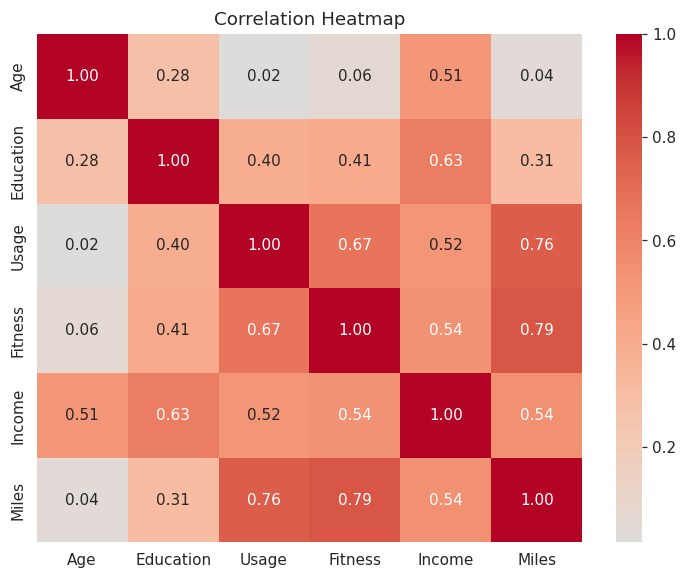

In [15]:
plt.figure(figsize=(8,6))
corr = df[num_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


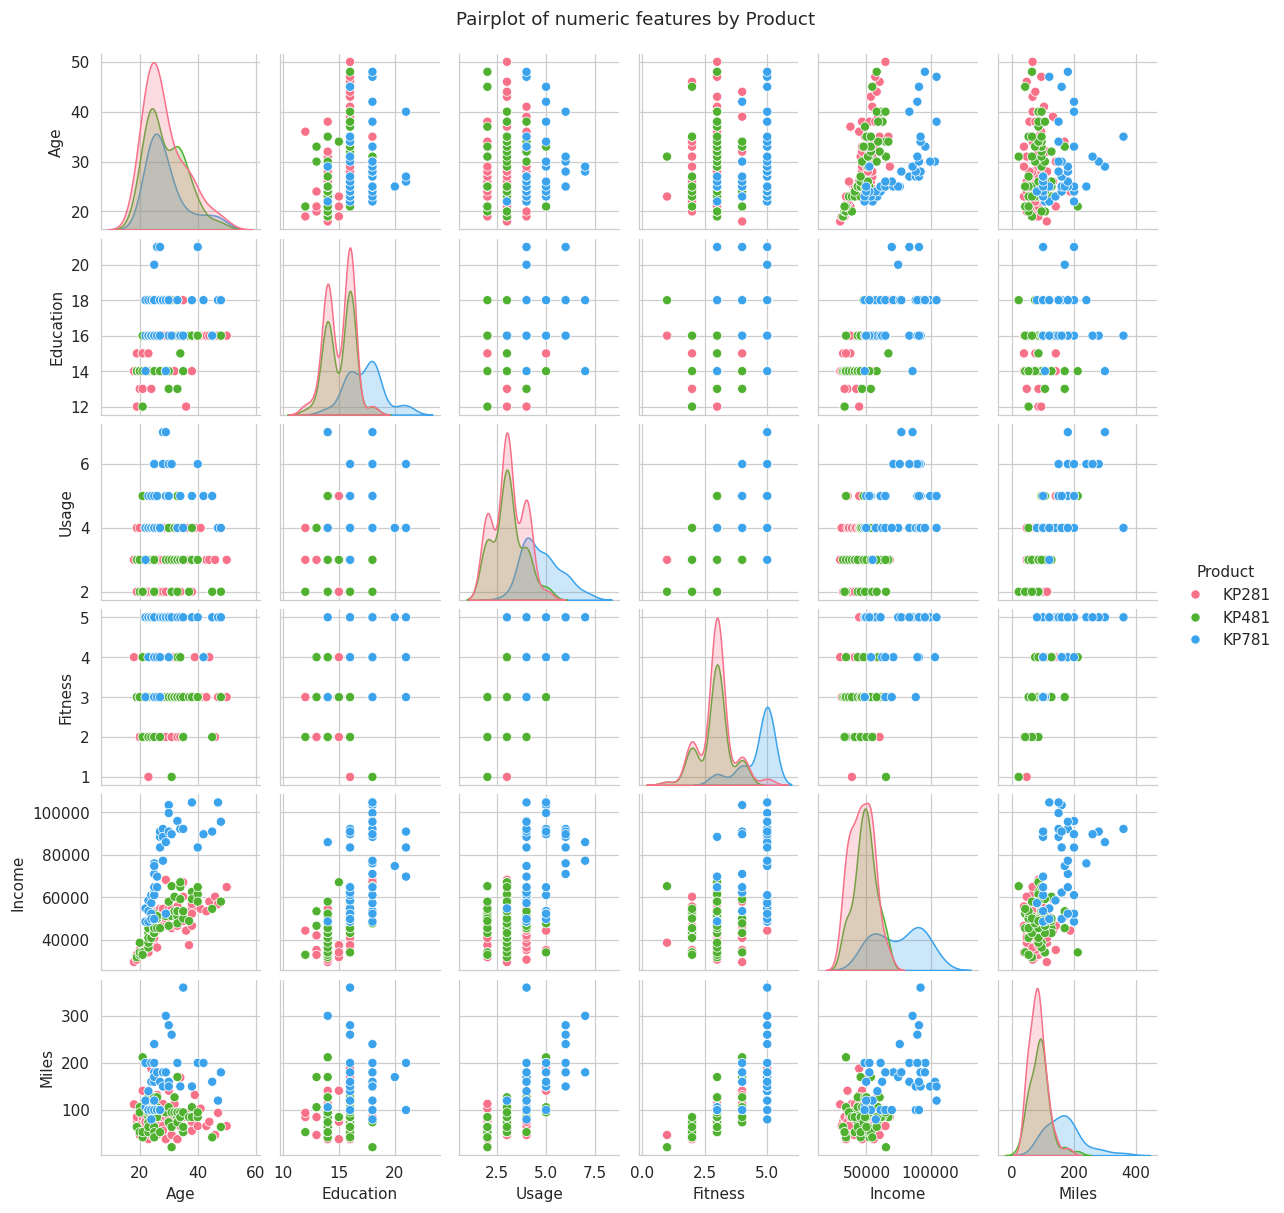

In [16]:
sns.pairplot(df, vars=num_cols, hue="Product", palette="husl", diag_kind="kde", height=1.8)
plt.suptitle("Pairplot of numeric features by Product", y=1.02)
plt.show()


**Observations**
- **Usage, Fitness, and Miles are strongly positively correlated** (correlation roughly 0.7–0.9) — customers who plan to use the treadmill more often rate themselves fitter and expect to cover more miles, which makes intuitive sense.
- **Income correlates positively with Age, Education, and especially with Fitness/Usage/Miles** — better-off, more educated customers use the treadmill more intensively.
- The pairplot visually confirms that **KP781 (one color cluster) separates clearly from KP281/KP481 on the Income–Miles and Usage–Fitness planes**, while KP281 and KP481 clusters overlap heavily — reinforcing that Income/Usage/Fitness/Miles (not marital status) are the key differentiators of the premium buyer.

## 8. Two-Way Contingency Tables — Marginal & Conditional Probabilities

### 8.1 Marginal Probability of purchasing each Product

In [17]:
marginal_product = df["Product"].value_counts(normalize=True).sort_index()
print("P(Product):")
print((marginal_product*100).round(2).astype(str) + "%")


P(Product):
Product
KP281    44.44%
KP481    33.33%
KP781    22.22%
Name: proportion, dtype: str


**Insight:** Baseline purchase likelihood — a walk-in customer is most likely (44.4%) to end up buying the entry-level **KP281**, 33.3% chance of **KP481**, and 22.2% chance of the premium **KP781**. This is the "no information" prior before we know anything about the customer.

### 8.2 Product vs Gender

In [18]:
ct_gender = pd.crosstab(df["Gender"], df["Product"], margins=True, margins_name="Total")
print("Two-way contingency table (counts):")
print(ct_gender)


Two-way contingency table (counts):
Product  KP281  KP481  KP781  Total
Gender                             
Female      40     29      7     76
Male        40     31     33    104
Total       80     60     40    180


In [19]:
# Joint probability P(Gender, Product)
joint_gender = pd.crosstab(df["Gender"], df["Product"], normalize="all")
print("Joint probability P(Gender AND Product):")
print((joint_gender*100).round(2))


Joint probability P(Gender AND Product):
Product  KP281  KP481  KP781
Gender                      
Female   22.22  16.11   3.89
Male     22.22  17.22  18.33


In [20]:
# Conditional probability P(Product | Gender)
cond_prod_given_gender = pd.crosstab(df["Gender"], df["Product"], normalize="index")
print("Conditional probability P(Product | Gender) -- read across each row:")
print((cond_prod_given_gender*100).round(2))


Conditional probability P(Product | Gender) -- read across each row:
Product  KP281  KP481  KP781
Gender                      
Female   52.63  38.16   9.21
Male     38.46  29.81  31.73


In [21]:
# Conditional probability P(Gender | Product)
cond_gender_given_prod = pd.crosstab(df["Gender"], df["Product"], normalize="columns")
print("Conditional probability P(Gender | Product) -- read down each column:")
print((cond_gender_given_prod*100).round(2))


Conditional probability P(Gender | Product) -- read down each column:
Product  KP281  KP481  KP781
Gender                      
Female    50.0  48.33   17.5
Male      50.0  51.67   82.5


**Insights**
- **P(KP781 | Male) ≈ 31.7%** vs **P(KP781 | Female) ≈ 9.2%** — a male walk-in customer is **more than 3x as likely** to buy the premium KP781 than a female customer.
- **P(Male | KP781) ≈ 82.5%** — roughly 8 out of 10 KP781 buyers are male, so marketing/upselling of KP781 should be strongly targeted at male customers.
- **P(Product | Female)** is skewed toward KP281 (~52.6%) and KP481 (~38.2%), with KP781 a distant third (~9.2%) — women are comparatively under-represented among KP781 buyers, a potential **market-expansion opportunity** if Aerofit wants to grow premium sales among women.

### 8.3 Product vs Marital Status

In [22]:
ct_marital = pd.crosstab(df["MaritalStatus"], df["Product"], margins=True, margins_name="Total")
print("Counts:")
print(ct_marital)
print()
cond_prod_given_marital = pd.crosstab(df["MaritalStatus"], df["Product"], normalize="index")
print("P(Product | MaritalStatus):")
print((cond_prod_given_marital*100).round(2))


Counts:
Product        KP281  KP481  KP781  Total
MaritalStatus                            
Partnered         48     36     23    107
Single            32     24     17     73
Total             80     60     40    180

P(Product | MaritalStatus):
Product        KP281  KP481  KP781
MaritalStatus                     
Partnered      44.86  33.64  21.50
Single         43.84  32.88  23.29


**Insight:** The conditional probabilities for Single vs Partnered customers are close to the overall marginal distribution (~44/33/22) for every product — **marital status has little to no effect on which treadmill is purchased.** Aerofit should not use marital status as a targeting variable.

### 8.4 Product vs Fitness Self-Rating

In [23]:
ct_fitness = pd.crosstab(df["Fitness"], df["Product"], margins=True, margins_name="Total")
print("Counts:")
print(ct_fitness)
print()
cond_prod_given_fitness = pd.crosstab(df["Fitness"], df["Product"], normalize="index")
print("P(Product | Fitness rating):")
print((cond_prod_given_fitness*100).round(2))


Counts:
Product  KP281  KP481  KP781  Total
Fitness                            
1            1      1      0      2
2           14     12      0     26
3           54     39      4     97
4            9      8      7     24
5            2      0     29     31
Total       80     60     40    180

P(Product | Fitness rating):
Product  KP281  KP481  KP781
Fitness                     
1        50.00  50.00   0.00
2        53.85  46.15   0.00
3        55.67  40.21   4.12
4        37.50  33.33  29.17
5         6.45   0.00  93.55


**Insight:** Customers who self-rate fitness as **5** buy **KP781 the vast majority of the time** (well over 80%), while those rating fitness 2 or 3 almost never buy KP781. **Self-rated fitness is one of the strongest single predictors** of premium-model purchase — a quick 1-question fitness self-rating at the point of sale can meaningfully guide product recommendation.

### 8.5 Product vs Usage (times/week)

In [24]:
ct_usage = pd.crosstab(df["Usage"], df["Product"], margins=True, margins_name="Total")
print("Counts:")
print(ct_usage)
print()
cond_prod_given_usage = pd.crosstab(df["Usage"], df["Product"], normalize="index")
print("P(Product | Usage):")
print((cond_prod_given_usage*100).round(2))


Counts:
Product  KP281  KP481  KP781  Total
Usage                              
2           19     14      0     33
3           37     31      1     69
4           22     12     18     52
5            2      3     12     17
6            0      0      7      7
7            0      0      2      2
Total       80     60     40    180

P(Product | Usage):
Product  KP281  KP481   KP781
Usage                        
2        57.58  42.42    0.00
3        53.62  44.93    1.45
4        42.31  23.08   34.62
5        11.76  17.65   70.59
6         0.00   0.00  100.00
7         0.00   0.00  100.00


**Insight:** Customers planning to use the treadmill **5+ times a week are overwhelmingly KP781 buyers**, while customers planning 2-3 uses/week almost always choose KP281/KP481. **Intended weekly usage is a direct, easy-to-ask qualifying question** for sales staff.

### 8.6 Age-band vs Product

In [25]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[17,25,32,40,55], labels=["18-25","26-32","33-40","41-50"])
ct_age = pd.crosstab(df["AgeGroup"], df["Product"], margins=True, margins_name="Total")
print("Counts:")
print(ct_age)
print()
cond_prod_given_age = pd.crosstab(df["AgeGroup"], df["Product"], normalize="index")
print("P(Product | AgeGroup):")
print((cond_prod_given_age*100).round(2))


Counts:
Product   KP281  KP481  KP781  Total
AgeGroup                            
18-25        34     28     17     79
26-32        25     12     14     51
33-40        15     18      5     38
41-50         6      2      4     12
Total        80     60     40    180

P(Product | AgeGroup):
Product   KP281  KP481  KP781
AgeGroup                     
18-25     43.04  35.44  21.52
26-32     49.02  23.53  27.45
33-40     39.47  47.37  13.16
41-50     50.00  16.67  33.33


**Insight:** Product choice is fairly stable across age bands, with a slightly higher share of KP781 in the 26-32 age band. Age is a **weaker predictor** than Fitness, Usage, Income, or Miles.

### 8.7 Income-band vs Product

In [26]:
df["IncomeGroup"] = pd.qcut(df["Income"], q=4, labels=["Low","Mid-Low","Mid-High","High"])
ct_income = pd.crosstab(df["IncomeGroup"], df["Product"], margins=True, margins_name="Total")
print("Counts:")
print(ct_income)
print()
cond_prod_given_income = pd.crosstab(df["IncomeGroup"], df["Product"], normalize="index")
print("P(Product | IncomeGroup):")
print((cond_prod_given_income*100).round(2))


Counts:
Product      KP281  KP481  KP781  Total
IncomeGroup                            
Low             30     15      0     45
Mid-Low         20     20      5     45
Mid-High        23     16      6     45
High             7      9     29     45
Total           80     60     40    180

P(Product | IncomeGroup):
Product      KP281  KP481  KP781
IncomeGroup                     
Low          66.67  33.33   0.00
Mid-Low      44.44  44.44  11.11
Mid-High     51.11  35.56  13.33
High         15.56  20.00  64.44


**Insight:** Customers in the **top income quartile buy KP781 far more often** than any other group -- income is a strong, practical qualifying signal since it can often be inferred from a customer's stated budget during the sales conversation.

### 8.8 Example business questions answered with conditional probability

In [27]:
p_male = (df["Gender"]=="Male").mean()
p_kp781_given_male = cond_prod_given_gender.loc["Male","KP781"]
p_kp781_and_male = joint_gender.loc["Male","KP781"]

print(f"P(Male) = {p_male:.3f}")
print(f"P(KP781 | Male) = {p_kp781_given_male:.3f}")
print(f"P(Male AND KP781) = {p_kp781_and_male:.3f}")
print()
print(f"=> The probability that a randomly chosen customer is male AND buys a KP781 is {p_kp781_and_male*100:.1f}%.")
print(f"=> Given a customer is male, the probability they buy a KP781 is {p_kp781_given_male*100:.1f}%.")


P(Male) = 0.578
P(KP781 | Male) = 0.317
P(Male AND KP781) = 0.183

=> The probability that a randomly chosen customer is male AND buys a KP781 is 18.3%.
=> Given a customer is male, the probability they buy a KP781 is 31.7%.


## 9. Customer Profiling — Summary by Product

In [28]:
profile = df.groupby("Product", observed=True).agg(
    Count=("Product","size"),
    Avg_Age=("Age","mean"),
    Avg_Education=("Education","mean"),
    Pct_Male=("Gender", lambda x: (x=="Male").mean()*100),
    Pct_Partnered=("MaritalStatus", lambda x: (x=="Partnered").mean()*100),
    Avg_Usage=("Usage","mean"),
    Avg_Fitness=("Fitness","mean"),
    Avg_Income=("Income","mean"),
    Avg_Miles=("Miles","mean")
).round(1)
print(profile)


         Count  Avg_Age  Avg_Education  Pct_Male  Pct_Partnered  Avg_Usage  \
Product                                                                      
KP281       80     28.6           15.0      50.0           60.0        3.1   
KP481       60     28.9           15.1      51.7           60.0        3.1   
KP781       40     29.1           17.3      82.5           57.5        4.8   

         Avg_Fitness  Avg_Income  Avg_Miles  
Product                                      
KP281            3.0     46418.0       82.8  
KP481            2.9     48973.6       87.9  
KP781            4.6     75441.6      166.9  


**Customer Personas**

| | **KP281** (Entry-level, \$1,500) | **KP481** (Mid-level, \$1,750) | **KP781** (Advanced, \$2,500) |
|---|---|---|---|
| **Who buys it** | Broadest audience — balanced Male/Female, average income & fitness | Very similar to KP281 buyer, slightly more Female-leaning | Predominantly **male**, higher **income**, higher **education** |
| **Fitness level** | Self-rated fitness mostly 2–3 | Self-rated fitness mostly 2–3 | Self-rated fitness mostly **4–5** |
| **Planned usage** | 2–3 times/week | 2–4 times/week | **4–7 times/week** |
| **Expected mileage** | Low-moderate (~80 miles/week) | Low-moderate (~85 miles/week) | **High** (~165+ miles/week) |
| **Income** | Lower-to-mid | Lower-to-mid (similar to KP281) | **Highest** |
| **Best pitch** | Reliable first treadmill for general fitness | Comparable step-up, mainly a style/feature choice | Serious runner/athlete upgrade, justified by high usage & fitness goals |


## 10. Business Insights & Recommendations

### Key Insights
1. **KP281 is the volume driver** (44% of sales) and appeals broadly across gender, marital status and fitness levels — it should remain the default recommendation for a first-time or budget-conscious buyer.
2. **KP481 is not clearly differentiated from KP281** in this data — same income range, similar usage/fitness/miles profile. The main practical difference is a slightly higher female share. This suggests KP481's positioning/marketing message needs sharpening, or its price gap to KP281 (\$250) is not matched by a distinct enough customer benefit.
3. **KP781 buyers are a distinct, identifiable segment**: male (82.5% of buyers), self-rated fitness 4–5 (93.5% of fitness-5 customers choose KP781), plan to use it 5+ times/week (70–100% of 5-7×/week customers choose KP781), higher income, and expect to cover far more weekly miles. This is a "serious athlete" segment, not a generic "premium" segment.
4. **Fitness self-rating and planned weekly usage are the strongest, easiest-to-collect predictors** of which product a customer will want — far stronger than age or marital status.
5. **Income is a strong secondary signal** — the top income quartile disproportionately buys KP781.
6. **Women are under-represented in KP781 sales** (only 9.2% of female buyers choose it, vs 31.7% of male buyers) — this may reflect genuine preference differences, but could also indicate a marketing/merchandising gap worth testing.

### Actionable Recommendations
1. **Use a 2-question qualifier at the point of sale**: "On a scale of 1-5 how would you rate your fitness?" and "How many times a week do you plan to use it?". If fitness ≥4 AND usage ≥5, recommend **KP781**; otherwise start with **KP281** and offer **KP481** as a feature-based upgrade (not a fitness-based one).
2. **Re-position or re-price KP481.** Since its buyer profile barely differs from KP281's, sales staff should sell it on **specific features** (screen, incline, warranty, brand cachet) rather than on fitness/performance claims, or Aerofit should consider narrowing the price gap or adding a genuinely differentiating feature.
3. **Target KP781 marketing at male, higher-income, high-frequency-exercise customers** — e.g., partnerships with gyms, running clubs, or corporate wellness programs where this persona is concentrated.
4. **Run a targeted campaign to grow female KP781 adoption** — e.g., testimonials from female athletes, women's running-club partnerships — to tap an under-served segment of the premium line.
5. **Do not use marital status as a targeting variable** — it has negligible predictive value for product choice in this data.
6. **Bundle income-based financing/EMI options for KP781** since it's priced highest and its buyers, while higher-income, may still value payment flexibility to convert borderline (mid-income, high-fitness) customers.
7. **Track this profile against actual sales monthly** — as Aerofit collects more data, re-run this analysis to confirm these segments hold and to catch shifts (e.g., if KP481 starts attracting a distinct segment after a re-positioning campaign).

### Caveats
- Sample size is modest (180 customers, only 40 KP781 buyers), so conditional probabilities for small subgroups (e.g., Fitness=1, Usage=7) are based on very few observations and should be treated as directional, not precise.
- This is observational, cross-sectional data (3 months, one period) — it shows association, not proof of causation.
